This notebook has been created by

s204248, Freja Tusindfryd Dollas & s204229, Søren Stange

# Comparative Social Structures in Fictional Universes: A Network and Text Analysis of the Wizarding World of Harry Potter and the Lord of the Rings

This is an explainer notebook made to show all of the programming which is the basis of the final project titled *Comparative Social Structures in Fictional Universes: A Network and Text Analysis of the Wizarding World of Harry Potter and the Lord of the Rings*.

#### Other files in the repositoire
This notebook utilises the results of two other notebooks in the repositoire. Namely 1) download_data.ipynb and 2) create_embedding.ipynb.

1) download_data.ipynb
In download_data.ipynb we crawl through the two fandom.com wiki-sites corresponding to **Harry Potter** (https://harrypotter.fandom.com/wiki/Harry_Potter) and **Lord of the Rings** (https://lotr.fandom.com/wiki/Main_Page). 

We crawl through each category found on the pages https://harrypotter.fandom.com/wiki/Harry_Potter/Category:Individuals and https://lotr.fandom.com/wiki/Main_Page/Category:Characters and extract all wiki pages found on these sites. These sites are then pruned taking only the ones containing infoboxes which relate to characters of the two universes. 

Two networks can then be created, one for the Harry Potter universe and one for the Lord of the Rings universe. Here the nodes of each network is the pages of characters and links between nodes are the hyperlinks in the wiki-pages content. We prune the network by removing all nodes which either don't link to any other or are not linked to by other pages. We then perform a final pruning by only selecting the largest weakly connected component for each network.

From all of the characters pages we extract info from the infoboxes and store these as node attributes along side the total number of words on each page. The attributes from the infoboxes we save are Blood-status (Pure-blood, half-blood, muggle) and House (Gryffendor, Slytherin, Ravenclaw, Hufflepuff) for Harry Potter and Culture and race for Lord of the Rings.

2) create_embedding.ipynb
In create_embedding.ipynb we use the implementation of the algorithm struc2vec from https://github.com/sebkaz/struc2vec/tree/master to create a vector representation of each node regarding their structural identity. This embedding will then be used in this notebook to determine role similarity between characters in the two character universes.

Lastly, a python script called util.py is created with usefull functions for this notebook.

#### Structure of the notebook
The rest of the notebook is structured as follows:
1) Network characterizations
2) Role similarity, data-mining, struc2vec
3) Sentiment analysis of the two universes

### Prelimary code

In [88]:
# Import all relevant libraries and modules
import pickle, requests, math, powerlaw
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from gensim.models import KeyedVectors
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from collections import Counter

from util import *

In [ ]:
# Load the data and networks
G       = load_network()
HP      = load_network('HP')
LOTR    = load_network('LOTR')

with open("data/Harry_Potter_Wiki_pages.pkl", "rb") as f: 
    HP_data = pickle.load(f)
with open("data/Lord_of_the_rings_Wiki_pages.pkl", "rb") as f:   
    LOTR_data = pickle.load(f)

combined_data = {}
for page in HP_data:
    combined_data[page['page_name'].replace(' ', '_')] = page['content']
for page in LOTR_data:
    combined_data[page['page_name'].replace(' ', '_')] = page['content']
    
with open("data/mapping.pkl", "rb") as f:
    mapping = pickle.load(f)
with open("data/reversed_mapping.pkl", "rb") as f:
    reversed_mapping = pickle.load(f)

emb = KeyedVectors.load_word2vec_format(f"data/embedding.emb", binary=False)
word_scores = load_LabTM()  #download LabTM list for sentiment analysis

NameError: name 'load_LabTM' is not defined

### 1) Network characterizations

In [ ]:
#Helper functions
def plot_centrality_distributions(G, network_name="Network"):
    measures = {
        "Degree": nx.degree_centrality(G),
        "Betweenness": nx.betweenness_centrality(G),
        "Eigenvector": nx.eigenvector_centrality(G, max_iter=1000)
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for i, (name, centrality) in enumerate(measures.items()):
        sorted_vals = sorted(centrality.values(), reverse=True)
        axes[i].plot(sorted_vals, marker='o')
        axes[i].set_title(f"{name} Centrality")
        axes[i].set_xlabel("Nodes (sorted)")
        axes[i].set_ylabel("Centrality value")
    
    fig.suptitle(f"Centrality Distributions - {network_name}", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()
    
    #top nodes
    for name, centrality in measures.items():
        top_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]
        print(f"\nTop 10 nodes by {name} Centrality ({network_name}):")
        for node, value in top_nodes:
            print(f"{node}: {value:.4f}")

def compare_degree_distributions(G1, G2, label1="Harry Potter", label2="LOTR", bins=30):
    plt.style.use("seaborn-v0_8-whitegrid")
    
    colors = {label1: "#b51512", label2: "#1670c4"}
    deg_types = ["in", "out", "total"]
    
    # Extract degree lists
    degs1 = {
        "in": [deg for _, deg in G1.in_degree() if deg>0],
        "out": [deg for _, deg in G1.out_degree() if deg>0],
        "total": [deg for _, deg in G1.degree() if deg>0]
    }
    degs2 = {
        "in": [deg for _, deg in G2.in_degree() if deg>0],
        "out": [deg for _, deg in G2.out_degree() if deg>0],
        "total": [deg for _, deg in G2.degree() if deg>0]
    }
    
    alphas1 = {k: powerlaw.Fit(v, verbose=False).alpha for k,v in degs1.items()}
    alphas2 = {k: powerlaw.Fit(v, verbose=False).alpha for k,v in degs2.items()}
    
    fig, axes = plt.subplots(1, 3, figsize=(16,5))
    
    for i, dtype in enumerate(deg_types):
        max_deg = max(max(degs1[dtype]), max(degs2[dtype]))
        bins_arr = np.linspace(0, max_deg, bins+1)
        
        # Plot histograms
        axes[i].hist(degs1[dtype], bins=bins_arr, alpha=0.6, color=colors[label1], label=label1)
        axes[i].hist(degs2[dtype], bins=bins_arr, alpha=0.6, color=colors[label2], label=label2, 
                     histtype='step', linewidth=2)
        
        axes[i].set_xlabel("Degree")
        axes[i].set_ylabel("Number of nodes")
        axes[i].set_title(f"{dtype.capitalize()}-degree distribution")
        
        # Only show legend on first subplot, lower-right corner
        if i == 0:
            axes[i].legend(loc='lower right')
        
        # Alpha text in top-right corner
        axes[i].text(0.95, 0.95, f"{label1} α={alphas1[dtype]:.2f}\n{label2} α={alphas2[dtype]:.2f}", 
                     transform=axes[i].transAxes,
                     verticalalignment='top',
                     horizontalalignment='right',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    fig.suptitle("Degree Distributions Comparison", fontsize=16, weight='bold')
    fig.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# --- Helper function: Freeman centralization ---
def freeman_centralization(centrality_dict):
    """Compute Freeman centralization for any centrality dict (values normalized 0-1)."""
    n = len(centrality_dict)
    max_c = max(centrality_dict.values())
    return sum(max_c - c for c in centrality_dict.values()) / (n - 1)

# --- Helper function: Gini coefficient ---
def gini(array):
    """Compute Gini coefficient of a numpy array"""
    array = np.array(array)
    if np.all(array == 0):
        return 0.0
    array = np.sort(array)
    n = array.shape[0]
    cumvals = np.cumsum(array)
    return (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n

def global_reaching_centrality(DG):
    """
    Directed Global Reaching Centrality (GRC).
    GRC = (1/(N-1)) * sum(max_reach - reach_i),
    where reach_i is fraction of nodes reachable from i (excluding i)
    following the definition of Coscia.
    """
    N = DG.number_of_nodes()
    if N <= 1:
        return 0.0
    # Precompute reach sizes
    reach_fracs = []
    nodes = list(DG.nodes())
    for u in nodes:
        # number of reachable nodes from u via directed paths (exclude u)
        reachable = nx.descendants(DG, u)  # uses directed reachability
        reach_fracs.append(len(reachable) / (N - 1))
    max_reach = max(reach_fracs) if reach_fracs else 0.0
    grc = sum(max_reach - r for r in reach_fracs) / (N - 1)
    return grc

# --- Analysis function ---
def analyze_network(G, name="Network"):
    n_nodes = len(G.nodes)
    n_edges = len(G.edges)
    avg_degree = sum(dict(G.degree()).values()) / n_nodes
    avg_clustering = nx.average_clustering(G)
    
    # Centrality metrics
    deg_cent = nx.degree_centrality(G)
    bet_cent = nx.betweenness_centrality(G, normalized=True)
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
    
    # Freeman centralization
    deg_centralization = freeman_centralization(deg_cent)
    bet_centralization = freeman_centralization(bet_cent)
    eig_centralization = freeman_centralization(eig_cent)
    
    # Gini coefficients (hierarchy measure)
    gini_degree = gini(list(dict(G.degree()).values()))
    gini_bet = gini(list(bet_cent.values()))
    gini_eig = gini(list(eig_cent.values()))
    
     # Global Reaching Centrality
    grc = global_reaching_centrality(G)

    
    # Summary dictionary
    summary = {
        "Nodes": n_nodes,
        "Edges": n_edges,
        "Avg Degree": avg_degree,
        "Avg Clustering": avg_clustering,
        "Degree Centralization": deg_centralization,
        "Betweenness Centralization": bet_centralization,
        "Eigenvector Centralization": eig_centralization,
        "Gini Degree": gini_degree,
        "Gini Betweenness": gini_bet, 
        "Gini Eigenvector": gini_eig,
        "Global reaching centrality": grc
    }
    
    return summary, deg_cent, bet_cent, eig_cent

In [ ]:
# Frejas kode her
plot_centrality_distributions(HP, network_name="HP Network")

In [ ]:
plot_centrality_distributions(LOTR, network_name="LOTR Network")

In [ ]:
compare_degree_distributions(HP, LOTR, label1="Harry Potter", label2="Lord of the Rings")

In [ ]:
# --- Run analysis for both networks ---
summary_HP, deg_HP, bet_HP, eig_HP = analyze_network(HP, "Harry Potter")
summary_LOTR, deg_LOTR, bet_LOTR, eig_LOTR = analyze_network(LOTR, "LOTR")

# --- Print summary table ---
import pandas as pd
df = pd.DataFrame([summary_HP, summary_LOTR], index=["Harry Potter", "LOTR"])
print(df[["Nodes","Edges","Avg Degree","Avg Clustering",
         "Degree Centralization","Betweenness Centralization",
         "Eigenvector Centralization","Gini Degree","Gini Betweenness", "Gini Eigenvector", "Global reaching centrality"]])

In [ ]:
# Compute PageRank
pr_HP = nx.pagerank(HP)
pr_LOTR = nx.pagerank(LOTR)

# Extract scores
scores_HP = list(pr_HP.values())
scores_LOTR = list(pr_LOTR.values())

# ---------- Helper functions ----------
def clean_name(name):
    return name.replace("_", " ")

def get_top(pr, n):
    top = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:n]
    names = [clean_name(node) for node, _ in top]
    scores = [score for _, score in top]
    return names, scores

# ---------- Get data ----------
top_n_line = 50
top_n_bar = 10

# Line plot values
top_hp_line = sorted(pr_HP.items(), key=lambda x: x[1], reverse=True)[:top_n_line]
top_lotr_line = sorted(pr_LOTR.items(), key=lambda x: x[1], reverse=True)[:top_n_line]

hp_scores_line = [v for _, v in top_hp_line]
lotr_scores_line = [v for _, v in top_lotr_line]

# Bar plot values
names_hp_bar, scores_hp_bar = get_top(pr_HP, top_n_bar)
names_lotr_bar, scores_lotr_bar = get_top(pr_LOTR, top_n_bar)

# Reverse for horizontal bars
names_hp_bar = names_hp_bar[::-1]
scores_hp_bar = scores_hp_bar[::-1]
names_lotr_bar = names_lotr_bar[::-1]
scores_lotr_bar = scores_lotr_bar[::-1]

# ---------- Create figure ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# =====================================================
#                 LEFT: Top-50 LINE PLOT
# =====================================================
ax1.plot(range(1, top_n_line + 1), hp_scores_line, marker='o',
         label="Harry Potter", color="#b51512")
ax1.plot(range(1, top_n_line + 1), lotr_scores_line, marker='o',
         label="LOTR", color="#1670c4")

ax1.set_title("Top 50 PageRank Nodes — Line Comparison", fontsize=13)
ax1.set_xlabel("Rank")
ax1.set_ylabel("PageRank")
ax1.legend()
ax1.grid(alpha=0.3)


# =====================================================
#                 RIGHT: Top-10 BAR PLOT
# =====================================================
ind = np.arange(top_n_bar)
width = 0.4

ax2.barh(ind + width/2, scores_hp_bar, height=width, label="Harry Potter", color="#b51512")
ax2.barh(ind - width/2, scores_lotr_bar, height=width, label="LOTR", color="#1670c4")

# Combined y-tick labels (HP over LOTR)
combined_labels = [f"{hp}\n{lotr}" for hp, lotr in zip(names_hp_bar, names_lotr_bar)]
ax2.set_yticks(ind)
ax2.set_yticklabels(combined_labels)

# Add values
for i in range(top_n_bar):
    ax2.text(scores_hp_bar[i] + 0.0002, ind[i] + width/2, f"{scores_hp_bar[i]:.3f}",
             va='center', fontsize=8)
    ax2.text(scores_lotr_bar[i] + 0.0002, ind[i] - width/2, f"{scores_lotr_bar[i]:.3f}",
             va='center', fontsize=8)

ax2.set_title("Top 10 PageRank Nodes — Side-by-Side", fontsize=13)
ax2.set_xlabel("PageRank")
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


### 2) Role similarity, data-mining, struc2vec

In [ ]:
#Helper functions here
def create_X(emb = emb):
    word_vectors = []

    for key in emb.index_to_key:
        word_vectors.append((int(key), emb[key]))

    word_vectors = sorted(word_vectors, key = lambda x: x[0])

    X = np.array([snd for _, snd in word_vectors])
    return (X - np.mean(X, axis = 0)) / np.std(X, axis = 0)

def select_best_gmm_k(X, k_min=2, k_max=30):
    bic_scores = []
    gmms = []
    
    for k in range(k_min, k_max + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            random_state=42
        )
        gmm.fit(X)
        bic = gmm.bic(X)
        bic_scores.append(bic)
        gmms.append(gmm)

    best_idx = np.argmin(bic_scores)
    best_k = k_min + best_idx
    best_gmm = gmms[best_idx]
    
    print(f"Best number of clusters (BIC): {best_k}")
    return best_k, best_gmm, bic_scores

def plot_pca_first_two(Z, labels):
    pca = PCA(n_components=2)
    Z_pca = pca.fit_transform(Z)

    labels = np.array(labels)

    unique_labels = np.unique(labels)

    plt.figure(figsize=(7, 7))

    for lab in unique_labels:
        idx = labels == lab
        plt.scatter(
            Z_pca[idx, 0],
            Z_pca[idx, 1],
            label=str(lab)
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA (first two components)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return Z_pca

# Declare helper functions
def create_corpus(wikipedia_data, partition, filter_n = 5):
    corpus = {}
    if isinstance(partition, dict):
        for key, nodes in partition.items():
            corpus[key] = ''
            for node in nodes:
                corpus[key] += wikipedia_data.get(node, "")

    elif isinstance(partition, list):
        for i, nodes in enumerate(partition):
            key = f'Community {i+1}'
            corpus[key] = ''
            for node in nodes:
                corpus[key] += wikipedia_data.get(node, "")

    lemmatizer = WordNetLemmatizer()
    for key, item in corpus.items():
        tokens = word_tokenize(item)
        tokens = [word for word in tokens if word.isalnum()]
        tokens = [word.lower() for word in tokens]
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        word_counts = Counter(tokens)
        tokens = [word for word in tokens if word_counts[word] >= filter_n]
        token_counts = {word: count for word, count in word_counts.items() if count >= filter_n}
        token_counts = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)
        corpus[key] = token_counts
    return corpus

def TF_IDF(corpus):
    corpus = corpus.copy()
    total_number_of_documents = len(corpus)
    word_list = {}
    for key, document in corpus.items():
        for word, amount in document:
            if word not in word_list:
                word_list[word] = 1
            else:
                word_list[word] += 1
    
    for key, document in corpus.items():
        total_number_of_words = sum([amount for _, amount in document])
        new_document = []
        for word, amount in document:
            TF = amount / total_number_of_words
            IDF = np.log(total_number_of_documents / word_list[word])
            new_document.append((word, amount, TF, IDF, TF * IDF))
            
        corpus[key] = sorted(new_document, key = lambda x: x[4], reverse=True)
    
    return corpus

def create_wordclouds(corpus, width = 400, height = 300):

    def normalize(x, a, b):
            return (x-b)/(a-b) * 1000
    n = len(corpus)
    if n == 0:
        print("Corpus is empty.")
        return

    # --- Figure layout ---
    rows = 2  # number of columns in the grid
    cols = math.ceil(n / rows)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 8))
    axes = axes.flatten() if n > 1 else [axes]

    # --- Create word clouds for each community ---
    for i, (key, token_counts) in enumerate(corpus.items()):
        # Convert list of tuples into a frequency dictionary
        TF_IDF_list = [TF_IDF for _,_,_,_,TF_IDF in token_counts]
        max_, min_ = max(TF_IDF_list), min(TF_IDF_list)
        
        freq_dict = []
        for word, _, _, _, TF_IDF in token_counts:
            freq_dict.append((word, normalize(TF_IDF, max_, min_)))
        freq_dict = dict(freq_dict)
        if not freq_dict:
            axes[i].set_visible(False)
            continue

        wc = WordCloud(
            width=width,
            height=height,
            background_color='white',
            colormap='viridis',
            random_state=42
        ).generate_from_frequencies(freq_dict)

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(key, fontsize=16)
        axes[i].axis('off')

    # --- Hide any unused subplots ---
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

def get_X_most_common_words(corpus, X = 10):
    for key, item in corpus.items():
        top_x = [word for word, _, _, _, _ in item[:X]]
        print(f'Group {key}: {top_x}')

def disparity_filter(G, alpha_threshold):
    # Create an empty graph of the same type
    backbone = G.__class__()
    backbone.add_nodes_from(G.nodes(data=True))

    # Compute normalized weights and significance for each node
    for i in G.nodes():
        k_i = len(G[i])
        if k_i <= 1:
            continue

        s_i = sum(G[i][j].get('viz_weight', 1.0) for j in G[i])
        for j in G[i]:
            w_ij = G[i][j].get('viz_weight', 1.0)
            p_ij = w_ij / s_i
            alpha_ij = 1 - (1 - p_ij) ** (k_i - 1)
            G[i][j]['alpha_' + str(i)] = alpha_ij

    # For undirected graphs, use the maximum significance (conservative choice)
    if not G.is_directed():
        for i, j, data in G.edges(data=True):
            alpha_i = data.get('alpha_' + str(i), 1)
            alpha_j = data.get('alpha_' + str(j), 1)
            alpha = min(alpha_i, alpha_j)
            if alpha < alpha_threshold:
                backbone.add_edge(i, j, **{'viz_weight': data.get('viz_weight', 1.0), 'alpha': alpha})
    else:
        for i, j, data in G.edges(data=True):
            alpha_i = data.get('alpha_' + str(i), 1)
            if alpha_i < alpha_threshold:
                backbone.add_edge(i, j, **{'viz_weight': data.get('viz_weight', 1.0), 'alpha': alpha_i})

    return backbone


def normalize(x, min_, max_):
    return (x - min_) / (max_ - min_) * 100

def plot_backbone(G, partition, alpha_threshold=0.5, node_size=50, edge_width=1,
                  nodes_cmap=plt.cm.tab20, edge_cmap=plt.cm.Blues, title=''):

    G = G.copy()

    plt.figure(figsize=(10,10))

    # Extract backbone
    backbone = disparity_filter(G, alpha_threshold)

    # Remove nodes with degree less than 5
    to_remove = [n for n, d in backbone.degree() if d < 5]
    backbone.remove_nodes_from(to_remove)

    # Select largest connected component
    components = nx.connected_components(backbone)
    largest = max(components, key=len)
    backbone = backbone.subgraph(largest).copy()

    # ---- PARTITION → NODE COLOR MAPPING ----
    # Build a reverse dictionary node → partition_id
    node_to_partition = {}
    for pid, nodes in partition.items():
        for n in nodes:
            node_to_partition[n] = pid

    # Generate stable numeric values for the colormap
    num_partitions = len(partition)
    # Each partition gets an integer 0..num_partitions-1
    values = []
    for n in backbone.nodes():
        if n in node_to_partition:
            values.append(node_to_partition[n])
        else:
            values.append(-1)  # fallback if missing (gets minimal color)

    # Layout
    try:
        pos = nx.forceatlas2_layout(backbone, seed=42)
    except:
        pos = nx.spring_layout(backbone, seed=42)

    # Draw edges
    nx.draw_networkx_edges(
        backbone, pos,
        width=edge_width,
        edge_color='grey',
        alpha=0.4
    )

    # Draw nodes colored by partition
    nx.draw_networkx_nodes(
        backbone, pos,
        node_size=node_size,
        node_color=values,
        cmap=nodes_cmap,
        alpha=1,
        vmin=0,
        vmax=num_partitions - 1
    )

    if len(title) == 0:
        title = f"Network Backbone ({backbone.number_of_nodes()} nodes, {backbone.number_of_edges()} edges)"

    plt.title(title, fontsize=22)
    plt.axis("off")
    plt.show()



Best number of clusters (BIC): 20


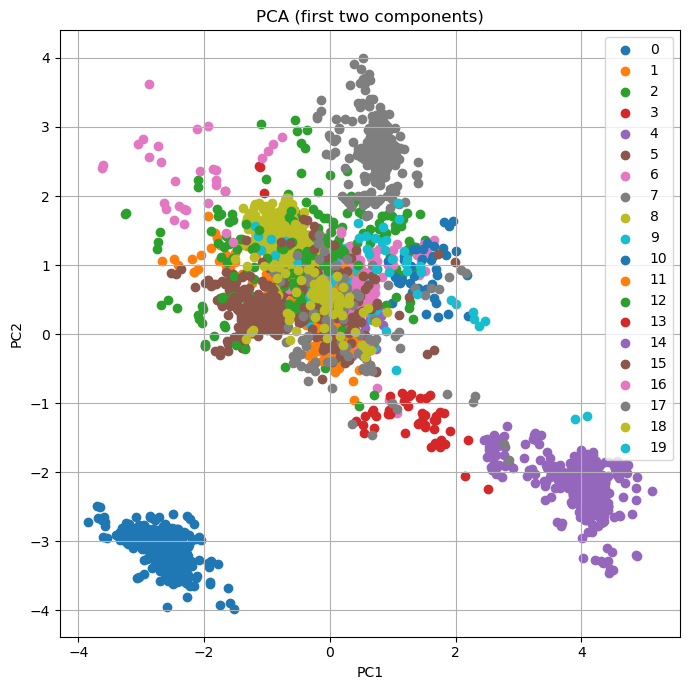

Group 0: ['tuft', 'grymm', 'smethwyck', 'malodora', 'lungorthin', 'plaque', 'gamwich', 'bole', 'madril', 'limus']
Group 1: ['shouren', 'antioch', 'mablung', 'puddifoot', 'spavin', 'arador', 'fréaláf', 'kogawa', 'spielman', 'gawrloc']
Group 2: ['bft', 'regulus', 'andromeda', 'myrtle', 'watcher', 'theseus', 'paternal', 'ernie', 'sebastian', 'queenie']
Group 3: ['sallow', 'solomon', 'imrahil', 'sage', 'sebastian', 'arwen', 'ori', 'torvus', 'dinah', 'willa']
Group 4: ['diamond', 'thranduil', 'gollum', 'buchanan', 'shaw', 'mouth', 'macgillony', 'ælfwine', 'langdon', 'balin']
Group 5: ['qwc', 'wbp', 'lotho', 'patrick', 'mopsus', 'hengist', 'hbpg', 'stalk', 'poag', 'cb']
Group 6: ['orgol', 'elurín', 'lobelia', 'treebeard', 'budge', 'odo', 'oakes', 'vána', 'gwaihir', 'adida']
Group 7: ['buchanan', 'charlatan', 'berúthiel', 'babbitty', 'warlock', 'angus', 'stump', 'gothmog', 'hamish', 'nessa']
Group 8: ['uin', 'whale', 'dp', 'gudgeon', 'lurtz', 'ollerton', 'gríma', 'waffling', 'goatleaf', 'belb

In [ ]:
# Struc2vec kode her
X = create_X()
best_k, best_gmm, bic_scores = select_best_gmm_k(X)
result = best_gmm.predict(X)
groups = {}
for x in set(result):
    idx = np.where(result == x)[0] + 1
    lst = [reversed_mapping[i] for i in idx]
    groups[x] = {'Names' : lst, 'index' : idx}

partition = {}
for x in set(result):
    idx = np.where(result == x)[0] + 1
    lst = [reversed_mapping[i] for i in idx]
    partition[x] = lst

P = {}
for n in G.nodes():
    for key, item in partition.items():
        if n in item:
            P[n] = key

Z_pca = plot_pca_first_two(X, result)

corpus = create_corpus(combined_data, partition)
c2 = TF_IDF(corpus)
get_X_most_common_words(c2)



In [ ]:
len(HP_data)

6114

In [ ]:
def calculate_sentiment(tokens, word_scores):
    valid_scores = [word_scores[w] for w in tokens if w in word_scores]
    if not valid_scores:
        return np.nan
    return np.mean(valid_scores)

def sentiment(G, data = combined_data, word_scores = word_scores):
    sentiments = []
    for node in G.nodes():
        tokens = word_tokenize(data.get(node))
        tokens = [t.lower() for t in tokens if t.isalpha()]
        sentiments.append((node, calculate_sentiment(tokens, word_scores)))

    return sentiments

sent = sentiment(G)

metrics = {key : {'sentiment' : [], 'length of content' : [], 'degree' : []} for key in partition.keys()}
degrees = G.degree()
for node, sentiment_score in sent:
    for key, item in partition.items():
        if node in item:
            metrics[key]['sentiment'].append(sentiment_score)
            metrics[key]['length of content'].append(len(combined_data[node].split(' ')))
            metrics[key]['degree'].append(degrees[node])


top = 5

for key, item in partition.items():
    group = key 
    characters = item
    HP_characters = sum([1 for node in characters if node in list(HP.nodes())])
    LOTR_characters = len(characters) - HP_characters
    degrees     = [node for node, _ in sorted([(c, d) for c,d in G.degree() if c in characters], key = lambda x: x[1], reverse = True)][:top]
    betweenness = [node for node, _ in sorted([(c,d) for c,d in nx.betweenness_centrality(G).items() if c in characters], key = lambda x: x[1], reverse = True)][:top]
    words       = [node for node, _ in sorted([(node, data['words']) for node, data in G.nodes(data=True) if node in characters], key = lambda x: x[1], reverse = True)][:top]

    item = metrics[key]
    print('#'*150)
    print(f'{f'Group {key}':<10} {f'Members: {len(item['sentiment'])}':>30}, {f'(HP/LOTR): {HP_characters}/{LOTR_characters}':>30} , {f'Average: sentiment {np.mean(item['sentiment']):.2f}':>30}, {f'Average words: {np.mean(item['length of content']):.2f}':>30}, {f'Average degree: {np.mean(item['degree']):.2f}':>30}')
    print()
    print(f'{"Rank":<5} {"Degree centrality":>40} {"Betweenness centrality":>40} {'Length of content':>40}')
    print('-' * 140)
    for i in range(len(degrees)):
        print(f'{i+1:<5} {degrees[i]:>40} {betweenness[i]:>40} {words[i]:>40}')
    print('-' * 140)
    print()
    print('#'*150)
    print()


######################################################################################################################################################
Group 0                      Members: 466,              (HP/LOTR): 386/80 ,        Average: sentiment 5.45,          Average words: 232.01,           Average degree: 4.20

Rank                         Degree centrality                   Betweenness centrality                        Length of content
--------------------------------------------------------------------------------------------------------------------------------------------
1                                       Maglor                           Mark_Overcliff                                   Amroth
2                                       Niënor                            David_Makehay                                   Maglor
3                                  Tar-Elendil                           Kris_Kolumbiko                          Wizard's_father
4                   

In [ ]:
P['Gandalf']

12

In [ ]:
character = ['Harry_Potter', 'Tom_Riddle', 'Ronald_Weasley', 'Sauron', 'Gandalf', 'Albus_Dumbledore', 'Legolas']

for c in character:
    distances = []
    for n in G.nodes():
        try:
            distances.append((n, np.linalg.norm(X[mapping[c] - 1,:] - X[mapping[n] - 1, :])))
        except:
            pass

    print(c, sorted(distances, key = lambda x: x[1])[1:11])

Harry_Potter [('Tom_Riddle', 1.0038115), ('Albus_Dumbledore', 3.5346384), ('Minerva_McGonagall', 4.0068035), ('Severus_Snape', 5.4765325), ('Rubeus_Hagrid', 5.888775), ('Draco_Malfoy', 6.442486), ("Jacob's_sibling", 6.632473), ('Horace_Slughorn', 7.4388776), ('Sirius_Black', 7.4492893), ('Hermione_Granger', 7.5268807)]
Tom_Riddle [('Harry_Potter', 1.0038115), ('Albus_Dumbledore', 3.2619123), ('Minerva_McGonagall', 3.5961356), ('Severus_Snape', 5.1866546), ('Rubeus_Hagrid', 5.4946237), ('Draco_Malfoy', 6.1373386), ("Jacob's_sibling", 6.257868), ('Sirius_Black', 7.082627), ('Horace_Slughorn', 7.0834923), ('Hermione_Granger', 7.2892804)]
Ronald_Weasley [('Hermione_Granger', 1.1449624), ("Jacob's_sibling", 5.303994), ('Rubeus_Hagrid', 5.558173), ('Albus_Dumbledore', 5.7962546), ('Severus_Snape', 6.248043), ('Ginevra_Weasley', 6.289453), ('Draco_Malfoy', 6.5791492), ('Neville_Longbottom', 6.677973), ('Minerva_McGonagall', 6.775444), ('Sirius_Black', 6.8143544)]
Sauron [('Boromir', 4.0901923

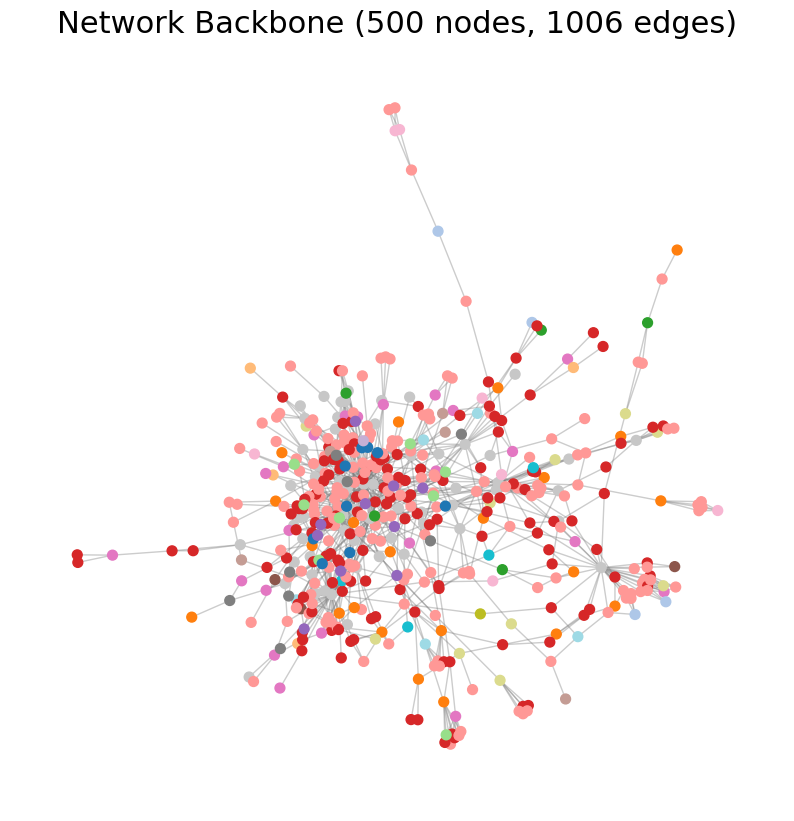

In [ ]:
plot_backbone(HP.to_undirected().copy(), partition, alpha_threshold=0.6)

### 3) Sentiment analysis

In [ ]:
mapping["1980s_Hogwarts_Gobstones_Tournament_champion's_parents"]

2

In [ ]:
# Sentiment analyse her